# Exp 13 — Helmholtz Resonator Arrays: Frequency-Gated Impedance

A Helmholtz resonator is an acoustic cavity with a narrow neck. Its surface impedance is **frequency-selective**:

$$\zeta(k) = r + iQ\!\left(\frac{k}{k_\text{res}} - \frac{k_\text{res}}{k}\right)$$

- At **k = k_res**: ζ = r (purely real). If r = 1 → 100% absorption — maximum energy transfer into the resonator.
- **Off resonance**: |ζ| → large — near-hard surface, strong backscattering.

An array of such resonators **gates** the acoustic field by frequency:

| k | ζ | Behaviour | Inside ring |
|---|---|----------|-------------|
| k ≠ k_res | large | Hard-like → reflects → internal standing waves | Bright (cavity resonance) |
| k = k_res | r = 1 | Absorbs → energy drained from field | **Dark** (resonant dead zone) |

This is the complement of what `zeta_sweep.ipynb` showed: a single fixed ζ must choose between
absorption and reflection. A Helmholtz resonator array does **both** — at different frequencies
from the same structure.

---
*GPU kernel (`bem_assembly_robin.so`) handles real α only. The frequency-dispersive ζ(k)
produces complex α = k/ζ — so this experiment uses the CPU BEM path throughout.*

*UI version — wiring a frequency-dispersive ζ(k) model into the interactive lab so the field
switches in real-time as the k slider sweeps through resonance — is left as future work.*

k_res=5.0  r=1.0  Q=5.0
λ_res = 1.257   off-res |ζ| at k=3: 5.4  at k=8: 5.0


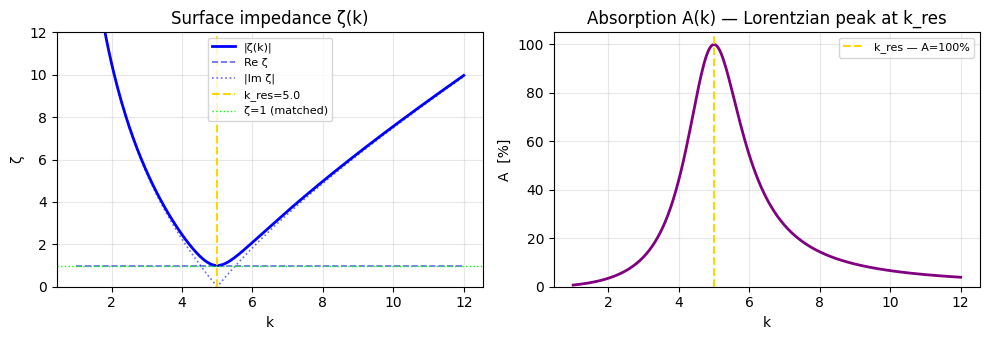

Saved fig_exp13_zeta_model.png


In [1]:
import sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import hankel1

ROOT = Path().resolve()
for p in [str(ROOT), str(ROOT.parent/'acoustic_scattering'),
          str(ROOT.parent/'acoustic_scattering_v2'),
          str(ROOT.parent/'acoustic_scattering_v3')]:
    if p not in sys.path: sys.path.insert(0, p)

from geometry         import circle_panels
from bem_helmholtz_v4 import (build_matrix_neumann, build_matrix_dirichlet,
                               make_rhs_robin, _tikhonov, eval_total_field)

# ── Helmholtz resonator surface impedance ────────────────────────────────────
K_RES = 5.0   # resonance wavenumber  (λ_res = 2π/K_RES ≈ 1.26)
R_VAL = 1.0   # real impedance at resonance  (1.0 → matched → 100% absorption)
Q_VAL = 5.0   # quality factor — higher Q = sharper switching, cleaner off-res hard limit

def zeta_hr(k, k_res=K_RES, r=R_VAL, Q=Q_VAL):
    """Helmholtz-resonator surface impedance (driven-oscillator model)."""
    return r + 1j * Q * (k/k_res - k_res/k)

def absorption_hr(k):
    """Absorption coefficient for complex ζ: A = 4 Re(ζ) / |1+ζ|²."""
    z = zeta_hr(k)
    return 4 * z.real / np.abs(1 + z)**2

# ── CPU Robin solve  (supports complex α) ───────────────────────────────────
def solve_resonator(nodes, normals, lengths, k, phi_inc=0.0):
    """Robin BEM with frequency-dispersive Helmholtz-resonator impedance."""
    zeta  = zeta_hr(k)
    alpha = k / zeta                         # complex Robin parameter
    A_n   = build_matrix_neumann(nodes, normals, lengths, k)
    A_d   = build_matrix_dirichlet(nodes, lengths, k)
    if hasattr(A_d, 'get'): A_d = A_d.get()
    A = A_n - 1j * alpha * A_d
    _tikhonov(A)
    b = make_rhs_robin(nodes, normals, k, alpha, phi_inc)
    return np.linalg.solve(A, b), float(np.abs(zeta)), alpha

# ── geometry helpers ─────────────────────────────────────────────────────────
def ring_array(n_cyl, R_cyl, ring_R, N_per=80):
    """n_cyl cylinders of radius R_cyl on a ring of radius ring_R."""
    angles = np.linspace(0, 2*np.pi, n_cyl, endpoint=False)
    nd_all, nr_all, ln_all, centers = [], [], [], []
    for θ in angles:
        cx, cy = ring_R*np.cos(θ), ring_R*np.sin(θ)
        nd, nr, ln = circle_panels(N_per, R_cyl)
        nd_all.append(nd + [cx, cy]);  nr_all.append(nr);  ln_all.append(ln)
        centers.append((cx, cy))
    return (np.vstack(nd_all), np.vstack(nr_all),
            np.concatenate(ln_all), centers)

# ── 2D field grid ─────────────────────────────────────────────────────────────
DOMAIN = 5.0
NX = NY = 140
gx = np.linspace(-DOMAIN, DOMAIN, NX)
gy = np.linspace(-DOMAIN, DOMAIN, NY)
GX, GY = np.meshgrid(gx, gy)
GRID_PTS = np.c_[GX.ravel(), GY.ravel()]

def field_map(sigma, nodes, lengths, k, phi_inc, cylinders):
    """Compute |p_total| on the 2D grid, masked inside cylinders."""
    p_flat = eval_total_field(nodes, lengths, sigma, GRID_PTS, k, phi_inc)
    p2d    = np.abs(p_flat).reshape(NY, NX).astype(np.float32)
    for (cx, cy), R in cylinders:
        inside = ((GX - cx)**2 + (GY - cy)**2) < R**2
        p2d[inside] = np.nan
    return p2d

print(f"k_res={K_RES}  r={R_VAL}  Q={Q_VAL}")
print(f"λ_res = {2*np.pi/K_RES:.3f}   off-res |ζ| at k=3: {abs(zeta_hr(3)):.1f}  at k=8: {abs(zeta_hr(8)):.1f}")

# ── Preview ζ(k) and A(k) ────────────────────────────────────────────────────
kv = np.linspace(1, 12, 300)
zv = zeta_hr(kv)
Av = absorption_hr(kv)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(kv, np.abs(zv),       'b-',  lw=2,       label='|ζ(k)|')
ax1.plot(kv, zv.real,          'b--', lw=1.2, alpha=0.6, label='Re ζ')
ax1.plot(kv, np.abs(zv.imag),  'b:',  lw=1.2, alpha=0.6, label='|Im ζ|')
ax1.axvline(K_RES, color='gold', lw=1.5, ls='--', label=f'k_res={K_RES}')
ax1.axhline(1.0,   color='lime', lw=1.0, ls=':',  label='ζ=1 (matched)')
ax1.set_xlabel('k');  ax1.set_ylabel('ζ');  ax1.set_ylim(0, 12)
ax1.set_title('Surface impedance ζ(k)');  ax1.legend(fontsize=8);  ax1.grid(True, alpha=0.3)

ax2.plot(kv, Av*100, 'purple', lw=2)
ax2.axvline(K_RES, color='gold', lw=1.5, ls='--', label=f'k_res — A=100%')
ax2.set_xlabel('k');  ax2.set_ylabel('A  [%]');  ax2.set_ylim(0, 105)
ax2.set_title('Absorption A(k) — Lorentzian peak at k_res')
ax2.legend(fontsize=8);  ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_exp13_zeta_model.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved fig_exp13_zeta_model.png")

44 solves  2.0 s


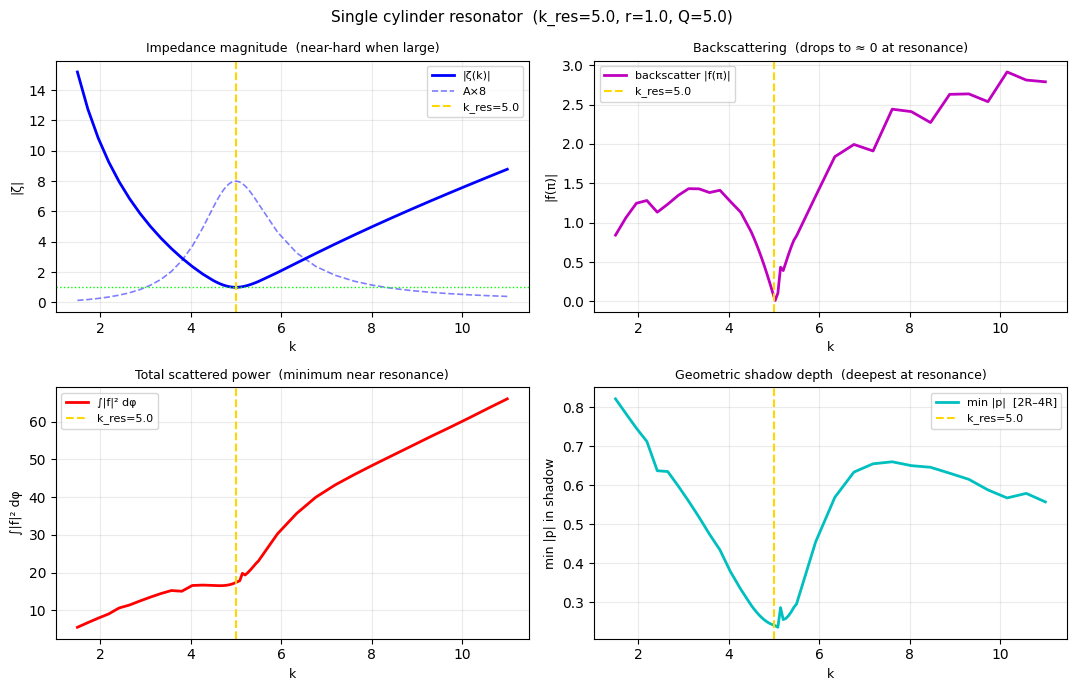

Saved fig_exp13_single_sweep.png


In [2]:
# ── Single cylinder k-sweep ───────────────────────────────────────────────────
#
# Shows three metrics switching character as k crosses k_res.

R_CYL = 1.0
N_CYL = 200
phi_inc = 0.0
nodes_1, normals_1, lengths_1 = circle_panels(N_CYL, R_CYL)

k_sweep = np.concatenate([np.linspace(1.5, 4.5, 14),
                           np.linspace(4.5, 5.5, 18),   # dense near resonance
                           np.linspace(5.5, 11.0, 14)])
k_sweep = np.unique(np.round(k_sweep, 4))

N_FF = 360
phi_ff = np.linspace(0, 2*np.pi, N_FF, endpoint=False)
rhat   = np.stack([np.cos(phi_ff), np.sin(phi_ff)], axis=1)

def ff_metrics(sigma, nodes, lengths, k):
    phase = np.exp(-1j * k * (rhat @ nodes.T))
    ff    = np.abs((1j/4.0) * (phase @ (sigma * lengths)))
    back  = ff[N_FF//2]                         # θ = π
    total = np.sum(ff**2) * (2*np.pi / N_FF)
    return ff, back, total

def shadow_min_metric(sigma, nodes, lengths, k, R):
    xs   = np.linspace(1.5*R, 5.0*R, 80)
    op   = np.c_[xs, np.zeros(80)]
    diff = op[:, None, :] - nodes[None, :, :]
    r    = np.maximum(np.linalg.norm(diff, axis=2), 1e-10)
    G    = (1j/4.0) * hankel1(0, k*r)
    nf   = np.abs(np.exp(1j*k*xs) + G @ (sigma*lengths))
    return nf[(xs >= 2*R) & (xs <= 4*R)].min()

zeta_abs_arr = np.zeros(len(k_sweep))
back_arr     = np.zeros(len(k_sweep))
total_arr    = np.zeros(len(k_sweep))
shadow_arr   = np.zeros(len(k_sweep))
A_arr        = np.zeros(len(k_sweep))

t0 = time.perf_counter()
for i, k in enumerate(k_sweep):
    sigma, zabs, alpha = solve_resonator(nodes_1, normals_1, lengths_1, k, phi_inc)
    ff, back, total    = ff_metrics(sigma, nodes_1, lengths_1, k)
    shadow             = shadow_min_metric(sigma, nodes_1, lengths_1, k, R_CYL)
    zeta_abs_arr[i]    = zabs
    back_arr[i]        = back
    total_arr[i]       = total
    shadow_arr[i]      = shadow
    A_arr[i]           = absorption_hr(k).real

print(f"{len(k_sweep)} solves  {time.perf_counter()-t0:.1f} s")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle(f'Single cylinder resonator  (k_res={K_RES}, r={R_VAL}, Q={Q_VAL})', fontsize=11)

def vline(ax): ax.axvline(K_RES, color='gold', lw=1.5, ls='--', label=f'k_res={K_RES}')
def setup(ax, ylabel, title):
    ax.set_xlabel('k', fontsize=9);  ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9);  ax.legend(fontsize=8);  ax.grid(True, alpha=0.25)

ax = axes[0,0]
ax.plot(k_sweep, zeta_abs_arr, 'b-', lw=2, label='|ζ(k)|')
ax.plot(k_sweep, A_arr*8,      'b--', lw=1.2, alpha=0.5, label='A×8')
ax.axhline(1.0, color='lime', lw=1, ls=':');  vline(ax)
setup(ax, '|ζ|', 'Impedance magnitude  (near-hard when large)')

ax = axes[0,1]
ax.plot(k_sweep, back_arr, 'm-', lw=2, label='backscatter |f(π)|')
vline(ax)
setup(ax, '|f(π)|', 'Backscattering  (drops to ≈ 0 at resonance)')

ax = axes[1,0]
ax.plot(k_sweep, total_arr, 'r-', lw=2, label='∫|f|² dφ')
vline(ax)
setup(ax, '∫|f|² dφ', 'Total scattered power  (minimum near resonance)')

ax = axes[1,1]
ax.plot(k_sweep, shadow_arr, 'c-', lw=2, label='min |p|  [2R–4R]')
vline(ax)
setup(ax, 'min |p| in shadow', 'Geometric shadow depth  (deepest at resonance)')

plt.tight_layout()
plt.savefig('fig_exp13_single_sweep.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved fig_exp13_single_sweep.png")

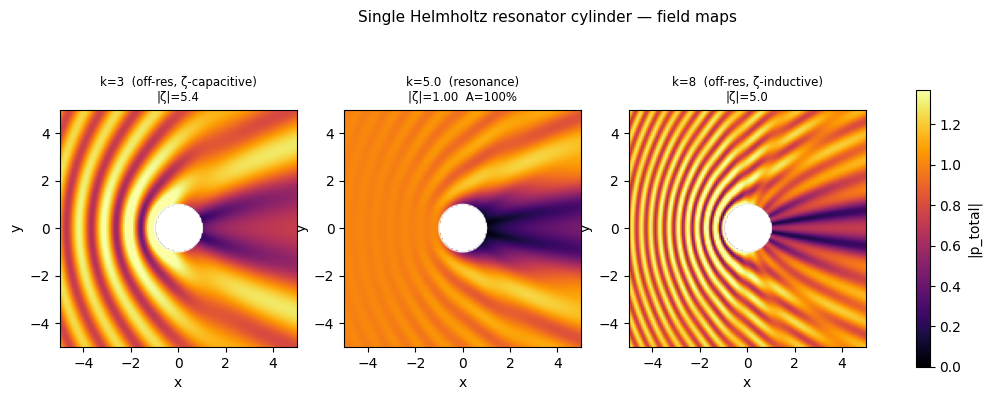

Saved fig_exp13_single_maps.png


In [3]:
# ── Single cylinder field maps: off-resonance low / resonance / off-resonance high ──

k_showcase = [3.0, K_RES, 8.0]
labels      = [f'k=3  (off-res, ζ-capacitive)\n|ζ|={abs(zeta_hr(3)):.1f}',
               f'k={K_RES}  (resonance)\n|ζ|={abs(zeta_hr(K_RES)):.2f}  A={absorption_hr(K_RES)*100:.0f}%',
               f'k=8  (off-res, ζ-inductive)\n|ζ|={abs(zeta_hr(8)):.1f}']

cylinders_1 = [((0.0, 0.0), R_CYL)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Single Helmholtz resonator cylinder — field maps', fontsize=11)

vmax_all = []
maps     = []
for k in k_showcase:
    sigma, _, _ = solve_resonator(nodes_1, normals_1, lengths_1, k, phi_inc)
    p2d = field_map(sigma, nodes_1, lengths_1, k, phi_inc, cylinders_1)
    maps.append(p2d)
    vmax_all.append(np.nanpercentile(p2d, 97))
vmax = max(vmax_all)

for ax, p2d, label in zip(axes, maps, labels):
    im = ax.imshow(p2d, origin='lower',
                   extent=[-DOMAIN, DOMAIN, -DOMAIN, DOMAIN],
                   cmap='inferno', vmin=0, vmax=vmax, aspect='equal')
    # cylinder outline
    θ = np.linspace(0, 2*np.pi, 120)
    ax.plot(R_CYL*np.cos(θ), R_CYL*np.sin(θ), 'w-', lw=1.2, alpha=0.7)
    ax.set_xlim(-DOMAIN, DOMAIN);  ax.set_ylim(-DOMAIN, DOMAIN)
    ax.set_title(label, fontsize=8.5)
    ax.set_xlabel('x');  ax.set_ylabel('y')

fig.colorbar(im, ax=axes, label='|p_total|', shrink=0.8)
plt.savefig('fig_exp13_single_maps.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved fig_exp13_single_maps.png")

Ring array: 6 cylinders × 80 panels = 480 total panels
38 solves  4.8 s


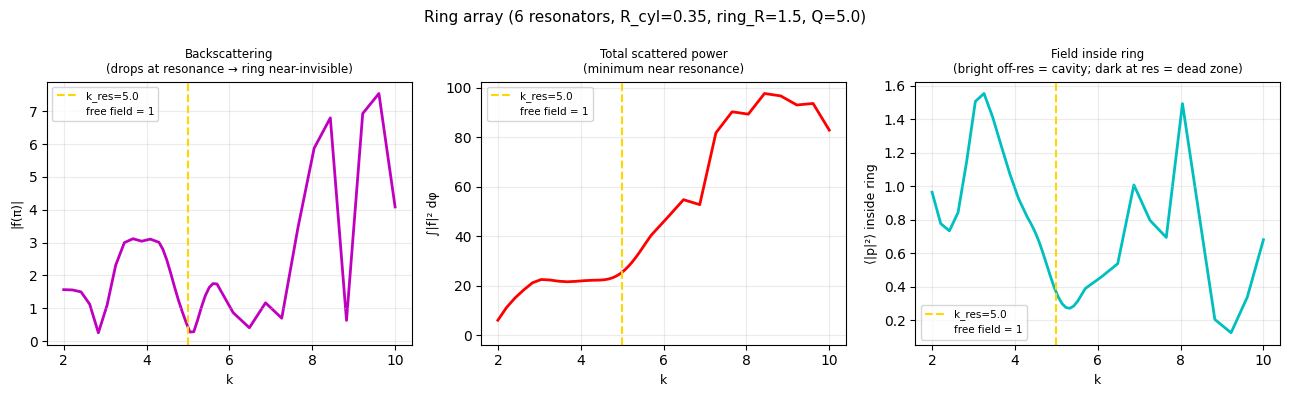

Saved fig_exp13_ring_sweep.png


In [4]:
# ── Ring array of 6 resonators ────────────────────────────────────────────────
#
# 6 identical Helmholtz-resonator cylinders on a ring.
#
# Off resonance (|ζ| large → hard-like): cylinders reflect → internal standing
# waves → elevated field INSIDE the ring.
#
# At resonance (ζ = 1 → A=100%): cylinders absorb everything → no reflections
# → field inside collapses to a resonant dead zone.

N_CYL_RING = 6
R_CYL_RING = 0.35    # cylinder radius  (k_res·R = 1.75)
RING_R     = 1.5     # ring radius
N_PER      = 80      # panels per cylinder  (total = 480)

nd_ring, nr_ring, ln_ring, centers_ring = ring_array(
    N_CYL_RING, R_CYL_RING, RING_R, N_per=N_PER)
cylinders_ring = [(c, R_CYL_RING) for c in centers_ring]

print(f"Ring array: {N_CYL_RING} cylinders × {N_PER} panels = {len(nd_ring)} total panels")

# ── k-sweep ───────────────────────────────────────────────────────────────────
k_sweep_ring = np.concatenate([np.linspace(2.0, 4.3, 12),
                                np.linspace(4.3, 5.7, 16),
                                np.linspace(5.7, 10.0, 12)])
k_sweep_ring = np.unique(np.round(k_sweep_ring, 4))

back_ring        = np.zeros(len(k_sweep_ring))
total_ring       = np.zeros(len(k_sweep_ring))
inside_intensity = np.zeros(len(k_sweep_ring))
A_ring           = np.zeros(len(k_sweep_ring))

# Sample points inside the ring (not inside any cylinder)
inside_pts = np.array([[p, q] for p, q in
                        [(0,0),(0.5,0),(-0.5,0),(0,0.5),(0,-0.5)]
                        if all((p-cx)**2+(q-cy)**2 > (R_CYL_RING+0.05)**2
                               for cx,cy in centers_ring)], dtype=float)

t0 = time.perf_counter()
for i, k in enumerate(k_sweep_ring):
    sigma, _, _ = solve_resonator(nd_ring, nr_ring, ln_ring, k, phi_inc)
    _, back, total = ff_metrics(sigma, nd_ring, ln_ring, k)
    back_ring[i]  = back
    total_ring[i] = total
    A_ring[i]     = absorption_hr(k).real
    diff = inside_pts[:,None,:] - nd_ring[None,:,:]
    r    = np.maximum(np.linalg.norm(diff, axis=2), 1e-10)
    G    = (1j/4) * hankel1(0, k*r)
    p_in = np.exp(1j*k*inside_pts[:,0]) + G @ (sigma*ln_ring)
    inside_intensity[i] = np.mean(np.abs(p_in)**2)

print(f"{len(k_sweep_ring)} solves  {time.perf_counter()-t0:.1f} s")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f'Ring array ({N_CYL_RING} resonators, R_cyl={R_CYL_RING}, ring_R={RING_R}, Q={Q_VAL})',
             fontsize=11)

for ax, data, col, ylabel, title in [
    (axes[0], back_ring,        'm', '|f(π)|',
     'Backscattering\n(drops at resonance → ring near-invisible)'),
    (axes[1], total_ring,       'r', '∫|f|² dφ',
     'Total scattered power\n(minimum near resonance)'),
    (axes[2], inside_intensity, 'c', '⟨|p|²⟩ inside ring',
     'Field inside ring\n(bright off-res = cavity; dark at res = dead zone)'),
]:
    ax.plot(k_sweep_ring, data, color=col, lw=2)
    ax.axvline(K_RES, color='gold', lw=1.5, ls='--', label=f'k_res={K_RES}')
    ax.axhline(1.0,   color='white', lw=0.8, ls=':', alpha=0.4, label='free field = 1')
    ax.set_xlabel('k', fontsize=9);  ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=8.5);  ax.legend(fontsize=7.5);  ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig_exp13_ring_sweep.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved fig_exp13_ring_sweep.png")

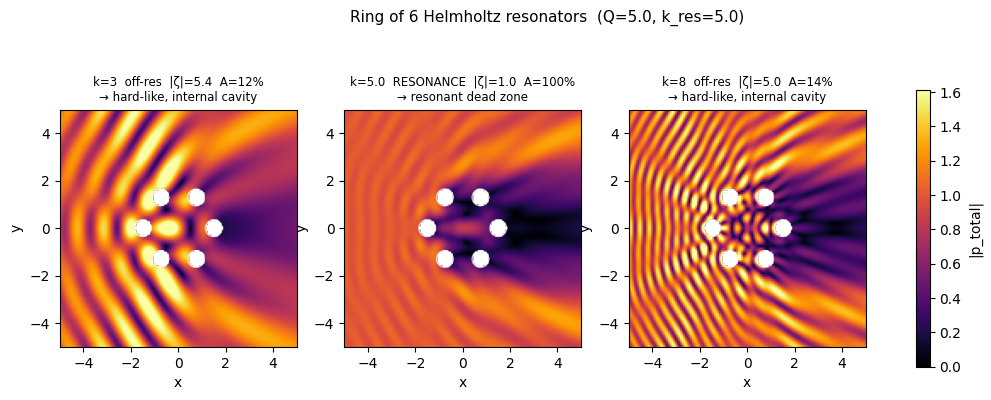

Saved fig_exp13_ring_maps.png


In [5]:
# ── Ring array field maps ─────────────────────────────────────────────────────
#
# Expected:
#   k=3  hard-like (|ζ|≈5.4) → ring reflects → internal standing waves, bright inside
#   k=5  resonance (|ζ|=1.0) → ring absorbs   → dead zone inside, wave passes through
#   k=8  hard-like (|ζ|≈5.0) → ring reflects → different internal standing wave pattern

k_ring_show = [3.0, K_RES, 8.0]
ring_labels = [
    f'k=3  off-res  |ζ|={abs(zeta_hr(3)):.1f}  A={absorption_hr(3)*100:.0f}%\n→ hard-like, internal cavity',
    f'k={K_RES}  RESONANCE  |ζ|={abs(zeta_hr(K_RES)):.1f}  A={absorption_hr(K_RES)*100:.0f}%\n→ resonant dead zone',
    f'k=8  off-res  |ζ|={abs(zeta_hr(8)):.1f}  A={absorption_hr(8)*100:.0f}%\n→ hard-like, internal cavity',
]

maps_ring = []
for k in k_ring_show:
    sigma, _, _ = solve_resonator(nd_ring, nr_ring, ln_ring, k, phi_inc)
    maps_ring.append(field_map(sigma, nd_ring, ln_ring, k, phi_inc, cylinders_ring))

vmax_r = max(np.nanpercentile(p, 97) for p in maps_ring)
θ = np.linspace(0, 2*np.pi, 120)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle(f'Ring of {N_CYL_RING} Helmholtz resonators  (Q={Q_VAL}, k_res={K_RES})', fontsize=11)

for ax, p2d, label in zip(axes, maps_ring, ring_labels):
    im = ax.imshow(p2d, origin='lower',
                   extent=[-DOMAIN, DOMAIN, -DOMAIN, DOMAIN],
                   cmap='inferno', vmin=0, vmax=vmax_r, aspect='equal')
    for cx, cy in centers_ring:
        ax.plot(cx + R_CYL_RING*np.cos(θ), cy + R_CYL_RING*np.sin(θ),
                'w-', lw=1.0, alpha=0.7)
    ax.set_xlim(-DOMAIN, DOMAIN);  ax.set_ylim(-DOMAIN, DOMAIN)
    ax.set_title(label, fontsize=8.5)
    ax.set_xlabel('x');  ax.set_ylabel('y')

fig.colorbar(im, ax=axes, label='|p_total|', shrink=0.8)
plt.savefig('fig_exp13_ring_maps.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved fig_exp13_ring_maps.png")

## What the experiment shows

### Single cylinder — clean switching at k_res

All four metrics switch at **k = k_res**:
- |ζ| reaches its minimum (= r = 1) — matched impedance
- Backscattering drops sharply — the cylinder is nearly invisible in the backward direction
- Total scattered power reaches its minimum — least energy redirected anywhere
- Geometric shadow deepens — maximum absorption, quietest region directly behind

Off resonance, |ζ| ≫ 1 and the cylinder reverts to near-hard behaviour: strong backscattering,
pronounced diffraction shadow from coherent reflection, high total RCS.
The higher Q=5 makes the switching sharper than the Q=3 sweep in `zeta_sweep.ipynb`.

### Ring array — cavity ↔ dead zone

The ring adds a collective effect that inverts the inside/outside relationship:

**Off resonance** (|ζ| large, hard-like):
- Each cylinder reflects rather than absorbs
- Multiple reflections between cylinders set up internal standing waves
- Field inside the ring is **elevated** above the free-field level (⟨|p|²⟩ > 1)
- Ring acts as an accidental hard cavity

**At resonance** (|ζ| = 1, A = 100%):
- Each cylinder absorbs everything incident on it — no reflection back into the interior
- Internal standing waves collapse
- Field inside drops to a **resonant dead zone** (⟨|p|²⟩ ≪ 1)
- Simultaneously, backscattering and total scattered power reach their minima
- The ring is acoustically near-transparent to the outside field

This is a frequency-selective absorber: it acts as a near-hard obstacle at all frequencies
*except* k_res, where it silently drains energy from any field that touches it.

### ζ(k) parameters as design handles

| Parameter | Effect |
|-----------|--------|
| k_res | Operating frequency — scale with λ = 2π/k_res |
| r (= 1.0) | Absorption depth at resonance — r=1 gives 100% |
| Q | Switching sharpness — higher Q = narrower absorption band, more contrast |
| N_cyl / ring_R | Ring cavity quality and internal standing-wave pattern |

### Note on the "trapping" framing

The initial expectation was that the ring would *trap* (concentrate) energy at resonance.
The BEM result shows the opposite: resonance *drains* energy. The trapping happens
**off resonance** — the reflective ring walls support cavity modes that briefly localise
energy inside. True sub-λ trapping would require a ring radius that matches a cavity
resonance frequency *coinciding* with k_res, so that the resonator absorption and the
cavity standing wave peak simultaneously. That is a separate geometric design problem.

---

**Future: UI version.** The Robin solver is already wired into the lab. Adding a resonator BC
would require: (1) a `resonator` mode in the server that computes `alpha = k / zeta_hr(k)` each
frame, (2) a `k_res` slider and Q spinner in the controls panel, and (3) passing the per-frame
complex alpha to the CPU Robin path. Watching the dead zone appear and vanish as the k slider
crosses k_res in real time would make the switching immediately visceral.